# imports

In [2]:
# Imports
import numpy as np
from numpy import nan
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.spatial.distance import cdist
from tqdm.auto import tqdm
import seaborn as sns
import importlib
from scipy.stats import bernoulli
import warnings
from plotter import *
from scipy.special import softmax
from scipy.spatial.distance import cdist
import gymnasium as gym
from gymnasium.envs.registration import register, registry, make, spec
import pickle
import copy
from itertools import product
import json
from functools import partial
from scipy.optimize import Bounds, minimize, differential_evolution
import multiprocess as mp
from pybads import BADS
import pymer4.models as pm

import IPython

import multiprocess as mp
import pingouin as pg
from scipy.special import expit

from agents import Farmer, BAMCP, CE
from utils import *
from runners import run_grid, run_bandit, run_emp, run_emp_enum
from MCTS import MonteCarloTreeSearch_AFC, MonteCarloTreeSearch_Bandit, MonteCarloTreeSearch_Emp


warnings.filterwarnings('ignore')


%load_ext autoreload
%autoreload 2

In [59]:
room_1 = [
    [1,0,0],
    [0,1,0]
    ]
room_2 = [
    [1,0,0],
    [0, 0.5,0.5],
    ]
ells = [0.5, 1.0, 2]
for ell in ells:
    for r, room in enumerate([room_1, room_2], start=1):
        print(f"Empowerment for ell={ell} in room {r}: {env.empowerment(room, ell)}")
    print('')

Empowerment for ell=0.5 in room 1: 2.0
Empowerment for ell=0.5 in room 2: 2.414213562373095

Empowerment for ell=1.0 in room 1: 2.0
Empowerment for ell=1.0 in room 2: 2.0

Empowerment for ell=2 in room 1: 2.0
Empowerment for ell=2 in room 2: 1.5



In [354]:
## make emp env
n_arms = 2
n_outcomes = 3
n_trials = 4
alpha = 0.1
ell = 1
policy = 'uniform_tail'
policy = 'bellman'
env = make_emp_env(n_arms, n_outcomes, n_trials, alpha, ell, seed = 1)

## make agent
agent = BAMCP(
    mcts_class=MonteCarloTreeSearch_Emp, run_fn=run_emp,
    n_samples=100000,
    exploration_constant=3,
    discount_factor=1,
    horizon=1,
    temp=1,
    lapse=0,
)


run_emp_enum(agent, env, policy = policy)

initial emp: 1.0
action 0, outcome 0, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.5917
action 0, outcome 1, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.5917
action 0, outcome 2, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.5917
action 1, outcome 0, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.5917
action 1, outcome 1, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.5917
action 1, outcome 2, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.5917
  trial   1/4  Q=[1.5917 1.5917]  pulled arm 0, outcome 0, empowerment reward 1.5128
action 0, outcome 0, p(o|a,h)=0.8462, V(h u (a,o), h-1)=1.6007
action 0, outcome 1, p(o|a,h)=0.0769, V(h u (a,o), h-1)=1.5425
action 0, outcome 2, p(o|a,h)=0.0769, V(h u (a,o), h-1)=1.5425
action 1, outcome 0, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.1544
action 1, outcome 1, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.8104
action 1, outcome 2, p(o|a,h)=0.3333, V(h u (a,o), h-1)=1.8104
  trial   2/4  Q=[1.5917 1.5917]  pulled arm 1, outcome 2, empowerment reward 1.7692
action 0, outcome 0, p(o|a,h)=0.8462, V(h u (a,o), h-1)=1

{'Q': array([[1.59171598, 1.59171598],
        [1.59171598, 1.59171598],
        [1.81039362, 1.81039362],
        [1.80267559, 1.80267559]]),
 'p_choice': array([[0.5, 0.5],
        [0.5, 0.5],
        [0.5, 0.5],
        [0.5, 0.5]]),
 'p_repeat_choice': array([nan, 0.5, 0.5, 0.5]),
 'actions': array([0, 1, 1, 1]),
 'outcomes': array([0, 2, 1, 2]),
 'emp_improvement': array([[1.59171598, 1.59171598],
        [1.05215124, 1.05215124],
        [1.02326596, 1.02326596],
        [1.        , 1.        ]]),
 'rewards': array([1.51282051, 1.76923077, 1.80267559, 1.81585082]),
 'cumulative_reward': array([1.51282051, 3.28205128, 5.08472687, 6.90057768]),
 'true_p_matrix': array([[9.99970869e-01, 2.40825110e-36, 2.91308436e-05],
        [1.90160427e-04, 3.65830454e-01, 6.33979385e-01]]),
 'posterior_p_matrix': array([[0.84615385, 0.07692308, 0.07692308],
        [0.03030303, 0.33333333, 0.63636364]]),
 'ell': 1}

In [565]:
## ell sweep: enumerate every reachable (action, outcome) history
## for the 3-trial / 2-arm / 2-outcome empowerment bandit and record
## Q-values, P(repeat previous action), and 1-step expected
## empowerment gain.

from runners import enumerate_emp_histories

n_arms = 2
n_outcomes = 2
n_trials = 3
alpha = 1
temp = 0.1
ells = [0.2, 
        1.0, 
        5]

df = enumerate_emp_histories(
    n_arms=n_arms, n_outcomes=n_outcomes, n_trials=n_trials,
    alpha=alpha, termination_arm=True, ells=ells, temp=temp,
)

print(f"{len(df)} rows  ({len(ells)} ells x {len(df)//len(ells)} histories)")
df.head(70)

63 rows  (3 ells x 21 histories)


,ell,t,history,history_str,prev_action,current_emp,p_repeat,best_a,Q_0,p_0,delta_emp_0,Q_1,p_1,delta_emp_1,Q_terminate,p_terminate,history_counts,history_counts_str
0,0.2,0,(),init,NaN,1.741101,NaN,0,1.807312,0.397493,0.051557,1.807312,0.397493,0.051557,1.741101,0.205013,(),
1,0.2,1,"((0, 0),)",a0o0,0.0,1.792658,0.354228,0,1.807312,0.354228,-0.002533,1.803161,0.339825,-0.008126,1.792658,0.305946,"(((0, 0), 1),)",a0o0:1
2,0.2,1,"((0, 1),)",a0o1,0.0,1.792658,0.354228,0,1.807312,0.354228,-0.002533,1.803161,0.339825,-0.008126,1.792658,0.305946,"(((0, 1), 1),)",a0o1:1
3,0.2,1,"((1, 0),)",a1o0,1.0,1.792658,0.354228,1,1.803161,0.339825,-0.008126,1.807312,0.354228,-0.002533,1.792658,0.305946,"(((1, 0), 1),)",a1o0:1
4,0.2,1,"((1, 1),)",a1o1,1.0,1.792658,0.354228,1,1.803161,0.339825,-0.008126,1.807312,0.354228,-0.002533,1.792658,0.305946,"(((1, 1), 1),)",a1o1:1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,5.0,2,"((1, 0), (1, 1))",a1o0-a1o1,1.0,0.062500,0.299148,0,0.162937,0.512966,0.100437,0.109010,0.299148,0.046510,0.062500,0.187886,"(((1, 0), 1), ((1, 1), 1))",a1o0:1-a1o1:1
59,5.0,2,"((1, 1), (0, 0))",a1o1-a0o0,0.0,0.263374,0.371581,0,0.300307,0.371581,0.036933,0.300307,0.371581,0.036933,0.263374,0.256837,"(((0, 0), 1), ((1, 1), 1))",a0o0:1-a1o1:1
60,5.0,2,"((1, 1), (0, 1))",a1o1-a0o1,0.0,0.135802,0.407867,0,0.215259,0.407867,0.079457,0.215259,0.407867,0.079457,0.135802,0.184265,"(((0, 1), 1), ((1, 1), 1))",a0o1:1-a1o1:1
61,5.0,2,"((1, 1), (1, 0))",a1o1-a1o0,1.0,0.062500,0.299148,0,0.162937,0.512966,0.100437,0.109010,0.299148,0.046510,0.062500,0.187886,"(((1, 0), 1), ((1, 1), 1))",a1o0:1-a1o1:1


In [561]:
## find the trials where the three ell agents disagree on the best action
disagree = df.groupby(['t', 'history_counts_str'])['best_a'].nunique() > 1
df_disagree = df.merge(disagree.rename('disagree').reset_index(), on=['t', 'history_counts_str'])
df_disagree[df_disagree['disagree']]

,ell,t,history,history_str,prev_action,current_emp,p_repeat,best_a,Q_0,p_0,delta_emp_0,Q_1,p_1,delta_emp_1,Q_terminate,p_terminate,history_counts,history_counts_str,disagree
1,0.2,1,"((0, 0),)",a0o0,0.0,2.476034,0.365047,0,2.497112,0.365047,0.012072,2.489793,0.339283,-0.014638,2.476034,0.295670,"(((0, 0), 1),)",a0o0:1,True
2,0.2,1,"((0, 1),)",a0o1,0.0,2.476034,0.365047,0,2.497112,0.365047,0.012072,2.489793,0.339283,-0.014638,2.476034,0.295670,"(((0, 1), 1),)",a0o1:1,True
3,0.2,1,"((0, 2),)",a0o2,0.0,2.476034,0.365047,0,2.497112,0.365047,0.012072,2.489793,0.339283,-0.014638,2.476034,0.295670,"(((0, 2), 1),)",a0o2:1,True
4,0.2,1,"((1, 0),)",a1o0,1.0,2.476034,0.365047,1,2.489793,0.339283,-0.014638,2.497112,0.365047,0.012072,2.476034,0.295670,"(((1, 0), 1),)",a1o0:1,True
5,0.2,1,"((1, 1),)",a1o1,1.0,2.476034,0.365047,1,2.489793,0.339283,-0.014638,2.497112,0.365047,0.012072,2.476034,0.295670,"(((1, 1), 1),)",a1o1:1,True
6,0.2,1,"((1, 2),)",a1o2,1.0,2.476034,0.365047,1,2.489793,0.339283,-0.014638,2.497112,0.365047,0.012072,2.476034,0.295670,"(((1, 2), 1),)",a1o2:1,True
7,0.2,2,"((0, 0), (0, 0))",a0o0-a0o0,0.0,2.508364,0.346019,2,2.506968,0.346019,-0.001395,2.493725,0.303100,-0.014638,2.508364,0.350881,"(((0, 0), 2),)",a0o0:2,True
14,0.2,2,"((0, 1), (0, 1))",a0o1-a0o1,0.0,2.508364,0.346019,2,2.506968,0.346019,-0.001395,2.493725,0.303100,-0.014638,2.508364,0.350881,"(((0, 1), 2),)",a0o1:2,True
21,0.2,2,"((0, 2), (0, 2))",a0o2-a0o2,0.0,2.508364,0.346019,2,2.506968,0.346019,-0.001395,2.493725,0.303100,-0.014638,2.508364,0.350881,"(((0, 2), 2),)",a0o2:2,True
28,0.2,2,"((1, 0), (1, 0))",a1o0-a1o0,1.0,2.508364,0.346019,2,2.493725,0.303100,-0.014638,2.506968,0.346019,-0.001395,2.508364,0.350881,"(((1, 0), 2),)",a1o0:2,True


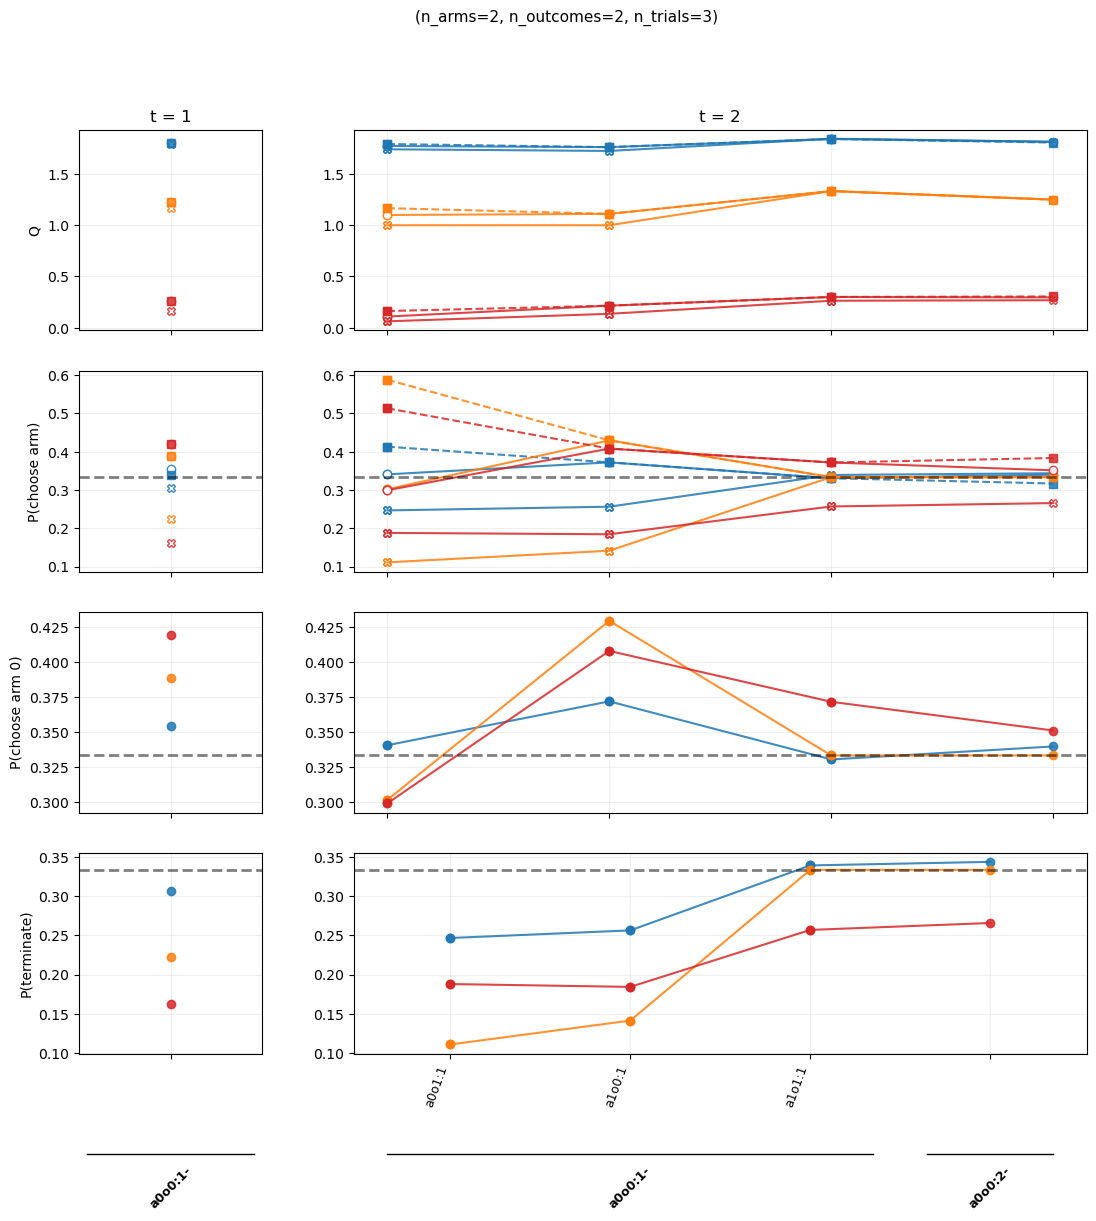

In [ ]:
# plot Q, P(choice), P(repeat), and 1-step empowerment gain across the three ells.
## columns = history length t (1, 4, 16 histories), rows = metric.

import matplotlib.pyplot as plt
import numpy as np

colors = ['tab:blue', 'tab:orange', 'tab:red']
ell_colors = {ells[e]: colors[e] for e in range(len(ells))}

x = 'history_str'
x = 'history_counts_str'

first_action_a0_only = True
first_obs_a0o0_only =  True
legend = False
group_brackets = True   ## hierarchical x-axis brackets (only when x == 'history_counts_str')
skip_t0 = True          ## drop the t=0 column
disagree_only = False   ## only plot histories where the different ells disagree on best_a

def _keep_history(h):
    if first_obs_a0o0_only:
        return h == 'init' or h.startswith('a0o0')
    if first_action_a0_only:
        return h == 'init' or h.startswith('a0')
    return True

## When grouping by counts, draw a hierarchical x-axis: the leaf tick label
## is the *rest* of history_counts_str after the first pair, and a bracket
## below shows the top-level group (the first pair, e.g. 'a0o0:2').
def _split_counts_str(h):
    if h in ('', 'init'):
        return (h, '')
    parts = h.split('-', 1)
    return (parts[0], parts[1] if len(parts) > 1 else '')

def _add_group_brackets(ax, hs, line_y=-0.5, label_y=-0.55):
    if not hs:
        return
    groups = []
    cur_top, _ = _split_counts_str(hs[0])
    cur_start = 0
    for i in range(1, len(hs)):
        top_i, _ = _split_counts_str(hs[i])
        if top_i != cur_top:
            groups.append((cur_top, cur_start, i - 1))
            cur_top, cur_start = top_i, i
    groups.append((cur_top, cur_start, len(hs) - 1))
    trans = ax.get_xaxis_transform()
    for top, s, e in groups:
        ax.plot([s - 0.35, e + 0.35], [line_y, line_y],
                color='k', lw=1, transform=trans, clip_on=False)
        ax.text((s + e) / 2, label_y, top+'-',
                ha='center', va='top', transform=trans, rotation = 45,
                fontsize=9, fontweight='bold')

## per-t history orderings + within-t x positions
hist_by_t = {}
x_local = {}
n_plot_trials = np.min([n_trials, 4])
for t in range(n_plot_trials):
    hs = (
        df[df['t'] == t][[x]]
        .drop_duplicates()
        .sort_values(x)[x]
        .tolist()
    )
    hs = [h for h in hs if _keep_history(h)]
    hist_by_t[t] = hs
    for i, h in enumerate(hs):
        x_local[(t, h)] = i
df_plot = df[df[x].map(_keep_history)].copy()
df_plot = df_plot[df_plot['t'] < n_plot_trials]
df_plot['x_local'] = df_plot.apply(lambda r: x_local[(r['t'], r[x])], axis=1)

## subselect where the different ell agents disagree on best_a
if disagree_only:
    disagree = df.groupby(['t', 'history_counts_str'])['best_a'].nunique() > 1
    df_plot = df_plot.merge(disagree.rename('disagree').reset_index(), on=['t', x])
    df_plot = df_plot[df_plot['disagree']]

ts = list(range(1 if skip_t0 else 0, n_plot_trials))
n_cols = len(ts)
width_ratios = [max(1, len(hist_by_t[t])) for t in ts]

# if x == 'history_str':
n_rows = 4
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(13, 12),
    sharey='row',
    gridspec_kw={'width_ratios': width_ratios},
)
# elif x == 'history_counts_str':
#     n_rows = 3
#     fig, axes = plt.subplots(
#         n_rows, n_cols,
#         figsize=(13, 9),
#         sharey='row',
#         gridspec_kw={'width_ratios': width_ratios},
#     )
if n_cols == 1:
    axes = axes.reshape(n_rows, 1)

styles = ['o-', 's--', 'd:']

for j, t in enumerate(ts):
    sub_t = df_plot[df_plot['t'] == t]
    hs = hist_by_t[t]
    xs_t = list(range(len(hs)))

    ## (1) Q-values
    ax = axes[0, j]
    for ell in ells:
        sub = sub_t[sub_t['ell'] == ell].sort_values('x_local')
        c = ell_colors[ell]
        markerfacecolors = ['white', str(c), str(c)]
        for a in range(n_arms):
            ax.plot(sub['x_local'], sub[f'Q_{a}'], styles[a], color=c, alpha=0.85, label=f'ell={ell}, arm {a}', markerfacecolor=markerfacecolors[a])
        if 'p_terminate' in df.columns:
            ax.plot(sub['x_local'], sub['Q_terminate'], 'X-', color=c, alpha=0.85, label=f'ell={ell}, terminate', markerfacecolor='none')
    ax.set_title(f't = {t}')
    if j == 0:
        ax.set_ylabel('Q')
    ax.grid(alpha=0.2)
    ax.set_xticks(xs_t)
    ax.set_xticklabels([])
    ax.tick_params(labelleft=True)
    if legend:
        if j == n_cols - 1:
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=3)

    ## (2) Choice probabilities P(arm a)
    ax = axes[1, j]
    for ell in ells:
        sub = sub_t[sub_t['ell'] == ell].sort_values('x_local')
        c = ell_colors[ell]
        markerfacecolors = ['white', str(c), str(c)]
        for a in range(n_arms):
            ax.plot(sub['x_local'], sub[f'p_{a}'], styles[a], color=c, alpha=0.85, label=f'ell={ell}, arm {a}', markerfacecolor=markerfacecolors[a])
        if 'p_terminate' in df.columns:
            ax.plot(sub['x_local'], sub['p_terminate'], 'X-', color=c, alpha=0.85, label=f'ell={ell}, terminate', markerfacecolor='none')
    chance = 1 / (n_arms + (1 if 'p_terminate' in df.columns else 0))
    ax.axhline(chance, color='k', linewidth=2, linestyle='--', alpha=0.5)
    if j == 0:
        ax.set_ylabel('P(choose arm)')
    ax.grid(alpha=0.2)
    ax.set_xticks(xs_t)
    ax.set_xticklabels([])
    ax.tick_params(labelleft=True)

    ## (3) P(repeat). Leave t=0 panel empty (no previous action) but keep
    ## the shared y-axis so the visible scale matches the data panels.
    if x == 'history_str':
        y_ax = 'p_repeat'
        y_label = 'P(repeat previous action)'
    elif x == 'history_counts_str':
        y_ax = 'p_0'
        y_label = 'P(choose arm 0)'
    ax = axes[2, j]
    if t == 0:
        ax.text(0.5, 0.5, 'no previous action',
                ha='center', va='center', transform=ax.transAxes,
                color='grey', fontsize=10, rotation=90)
        ax.set_xticks([])
    else:
        for ell in ells:
            sub = sub_t[sub_t['ell'] == ell].sort_values('x_local')
            ax.plot(sub['x_local'], sub[y_ax], 'o-',
                    color=ell_colors[ell], alpha=0.85, label=f'ell={ell}')
        chance = 1 / (n_arms + (1 if 'p_terminate' in df.columns else 0))
        ax.axhline(chance, color='k', linewidth=2, linestyle='--', alpha=0.5)
        ax.set_xticks(xs_t)
        ax.set_xticklabels([])
    ax.grid(alpha=0.2)
    ax.tick_params(labelleft=True)
    if j == 0:
        ax.set_ylabel(y_label)

    ## (4) 1-step expected empowerment gain OR p(terminate)
    ax = axes[-1, j]
    if 'p_terminate' in df.columns:
        y_ax = 'p_terminate'
        y_label = 'P(terminate)'
        y_baseline = 1 / (n_arms + 1)
    else:
        y_ax = 'delta_emp_0'
        y_label = r'$\Delta$ Emp (one-step)'
        y_baseline = 0
    for ell in ells:
        sub = sub_t[sub_t['ell'] == ell].sort_values('x_local')
        c = ell_colors[ell]
        if 'p_terminate' in df.columns:
            ax.plot(sub['x_local'], sub['p_terminate'], 'o-', color=c, alpha=0.85,
                    label=f'ell={ell}')
        else:
            ax.plot(sub['x_local'], sub['delta_emp_0'], 'o-', color=c, alpha=0.85,
                    label=f'ell={ell}, arm 0')
            ax.plot(sub['x_local'], sub['delta_emp_1'], 's--', color=c, alpha=0.85,
                    label=f'ell={ell}, arm 1', markerfacecolor='none')
    ax.set_xticks(xs_t)
    if x == 'history_counts_str':
        leaf_labels = [_split_counts_str(h)[1] for h in hs]
        ax.set_xticklabels(leaf_labels, rotation=70, ha='right', fontsize=9)
        if group_brackets:
            _add_group_brackets(ax, hs)
    else:
        ax.set_xticklabels(hs, rotation=70, ha='right', fontsize=9)
    ax.grid(alpha=0.2)
    ax.tick_params(labelleft=True)
    ax.axhline(y_baseline, color='k', linewidth=2, linestyle='--', alpha=0.5)
    if j == 0:
        ax.set_ylabel(y_label)

fig.suptitle(
    f'(n_arms={n_arms}, n_outcomes={n_outcomes}, n_trials={n_trials})',
    fontsize=11,
)
plt.tight_layout()
plt.show()